## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
from fuzzywuzzy import fuzz
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")

from preprocessing_utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x000001E7E729E2C0> [RTYPES.NILSXP]

In [3]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_EL = 'κεντρικης μακεδονιας'

In [4]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_NUTS3_2010-2022_filled_meantemps.csv', encoding=enc)
wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Cases_NUTS3_2010-2022.csv', encoding=enc)

In [5]:
timeline_file.head()

,nuts3,nuts2,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall
0,ημαθιας,κεντρικης μακεδονιας,21.961450,40.522520,2010-01-01,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14199.000000,13669.000000,14199.000000,NaN,NaN,NaN,13669.000000,NaN,NaN,NaN,2.030213
1,ημαθιας,κεντρικης μακεδονιας,21.961450,40.522520,2010-01-02,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14199.000000,13669.000000,14199.000000,NaN,NaN,NaN,13669.000000,NaN,NaN,NaN,1.997432
2,ημαθιας,κεντρικης μακεδονιας,21.961450,40.522520,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14199.000000,13669.000000,14199.000000,NaN,NaN,NaN,13669.000000,NaN,NaN,NaN,0.882009
3,ημαθιας,κεντρικης μακεδονιας,21.961450,40.522520,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14199.000000,13669.000000,14199.000000,NaN,NaN,NaN,13669.000000,NaN,NaN,NaN,1.242316
4,ημαθιας,κεντρικης μακεδονιας,21.961450,40.522520,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14199.000000,13669.000000,14199.000000,NaN,NaN,NaN,13669.000000,NaN,NaN,NaN,0.093469


In [6]:
wnv_file.head()

,nuts2,nuts3,dt_placement,cases
0,κεντρικης μακεδονιας,ημαθιας,2010-06,0
1,κεντρικης μακεδονιας,ημαθιας,2010-07,6
2,κεντρικης μακεδονιας,ημαθιας,2010-08,36
3,κεντρικης μακεδονιας,ημαθιας,2010-09,7
4,κεντρικης μακεδονιας,ημαθιας,2010-10,0


In [7]:
timeline_file[['nuts3', 'dt_placement']].value_counts().sort_values(ascending=False)

nuts3    dt_placement
σερρων   2010-01-02      154
         2010-01-17      154
         2010-01-03      154
         2010-01-04      154
         2010-01-05      154
                        ... 
πιεριας  2022-12-28       45
         2022-12-29       45
         2022-12-23       45
         2022-12-14       45
         2022-12-31       45
Length: 33236, dtype: int64

In [8]:
wnv_file[['nuts3', 'dt_placement']].value_counts().sort_values(ascending=False)

nuts3       dt_placement
ημαθιας     2010-06         1
            2012-07         1
            2010-10         1
            2010-11         1
            2011-06         1
                           ..
χαλκιδικης  2022-07         1
            2022-08         1
            2022-09         1
            2022-10         1
            2022-11         1
Length: 378, dtype: int64

In [9]:
#timeline_file.drop(columns=['Unnamed: 0'], inplace=True)
timeline_file.rename(columns={"region": "nuts2"}, inplace=True)

In [10]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [11]:
timeline_file = convert_temperature(timeline_file)

In [12]:
timeline_file

,nuts3,nuts2,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean
0,ημαθιας,κεντρικης μακεδονιας,21.961450,40.522520,2010-01-01,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.830000,0.230000,10.830000,NaN,NaN,NaN,0.230000,NaN,NaN,NaN,2.030213,5.530000,5.530000,NaN,NaN,NaN
1,ημαθιας,κεντρικης μακεδονιας,21.961450,40.522520,2010-01-02,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.830000,0.230000,10.830000,NaN,NaN,NaN,0.230000,NaN,NaN,NaN,1.997432,5.530000,5.530000,NaN,NaN,NaN
2,ημαθιας,κεντρικης μακεδονιας,21.961450,40.522520,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.830000,0.230000,10.830000,NaN,NaN,NaN,0.230000,NaN,NaN,NaN,0.882009,5.530000,5.530000,NaN,NaN,NaN
3,ημαθιας,κεντρικης μακεδονιας,21.961450,40.522520,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.830000,0.230000,10.830000,NaN,NaN,NaN,0.230000,NaN,NaN,NaN,1.242316,5.530000,5.530000,NaN,NaN,NaN
4,ημαθιας,κεντρικης μακεδονιας,21.961450,40.522520,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.830000,0.230000,10.830000,NaN,NaN,NaN,0.230000,NaN,NaN,NaN,0.093469,5.530000,5.530000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3067203,χαλκιδικης,κεντρικης μακεδονιας,23.558210,40.414170,2022-12-27,27,12,2022,0.584723,0.370539,-0.435388,-0.370539,0.555288,0.353597,-0.402127,-0.353597,0.050305,0.036717,0.050299,0.036717,11.650000,6.790000,8.156452,10.717143,10.374516,10.374516,1.886129,2.433571,1.273871,1.273871,0.000000,9.220000,5.021290,6.575357,5.824194,5.824194
3067204,χαλκιδικης,κεντρικης μακεδονιας,23.558210,40.414170,2022-12-28,28,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.650000,6.790000,8.156452,10.717143,10.374516,10.374516,1.886129,2.433571,1.273871,1.273871,0.000000,9.220000,5.021290,6.575357,5.824194,5.824194
3067205,χαλκιδικης,κεντρικης μακεδονιας,23.558210,40.414170,2022-12-29,29,12,2022,0.584723,0.370539,-0.435388,-0.370539,0.555288,0.353597,-0.402127,-0.353597,0.050305,0.036717,0.050299,0.036717,11.650000,5.130000,8.156452,10.717143,10.374516,10.374516,1.886129,2.433571,1.273871,1.273871,0.000000,8.390000,5.021290,6.575357,5.824194,5.824194
3067206,χαλκιδικης,κεντρικης μακεδονιας,23.558210,40.414170,2022-12-30,30,12,2022,0.584723,0.370539,-0.435388,-0.370539,0.555288,0.353597,-0.402127,-0.353597,0.050305,0.036717,0.050299,0.036717,11.650000,5.310000,8.156452,10.717143,10.374516,10.374516,1.886129,2.433571,1.273871,1.273871,0.000000,8.480000,5.021290,6.575357,5.824194,5.824194


In [13]:
grouped = timeline_file.groupby(['dt_placement', 'nuts3', 'nuts2'], as_index = False)
dataset_grouped = grouped.mean()
dataset_grouped

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean
0,2010-01-01,ημαθιας,κεντρικης μακεδονιας,22.215876,40.552658,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.092545,6.958148,12.092545,NaN,NaN,NaN,6.958148,NaN,NaN,NaN,1.216681,9.571481,9.571481,NaN,NaN,NaN
1,2010-01-01,θεσσαλονικης,κεντρικης μακεδονιας,23.139532,40.695359,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.860079,7.648268,13.860079,NaN,NaN,NaN,7.648268,NaN,NaN,NaN,0.020066,10.754173,10.754173,NaN,NaN,NaN
2,2010-01-01,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.183407,7.272857,12.183407,NaN,NaN,NaN,7.272857,NaN,NaN,NaN,0.000223,9.728132,9.728132,NaN,NaN,NaN
3,2010-01-01,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.261136,6.675227,11.261136,NaN,NaN,NaN,6.675227,NaN,NaN,NaN,0.406945,8.968182,8.968182,NaN,NaN,NaN
4,2010-01-01,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.961111,9.068667,15.961111,NaN,NaN,NaN,9.068667,NaN,NaN,NaN,1.073789,12.514889,12.514889,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33231,2022-12-31,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,31.000000,12.000000,2022.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.991758,3.148242,8.187343,13.880495,14.817068,14.817068,-0.488093,1.139192,0.183244,0.183244,0.000000,7.570000,3.849625,7.509843,7.500156,7.500156
33232,2022-12-31,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,31.000000,12.000000,2022.000000,0.360782,0.044948,-0.290089,-0.044948,0.358655,0.041134,-0.285736,-0.041134,0.043845,0.042941,0.045696,0.042941,11.252500,3.386818,8.040870,12.913580,12.829817,12.829817,-0.570395,1.041250,0.131540,0.131540,0.000000,7.319659,3.735237,6.977415,6.480678,6.480678
33233,2022-12-31,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,31.000000,12.000000,2022.000000,0.292489,0.052709,-0.241228,-0.052709,0.246753,0.057316,-0.198783,-0.057316,0.037453,0.033593,0.033740,0.033593,11.800667,4.870000,8.892165,12.937206,12.690186,12.690186,0.455459,2.196651,1.193384,1.193384,0.000000,8.335333,4.673812,7.566929,6.941785,6.941785
33234,2022-12-31,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,31.000000,12.000000,2022.000000,0.242057,-0.020198,-0.221376,0.020198,0.211338,0.029242,-0.180503,-0.029242,0.037578,0.040732,0.033145,0.040732,11.153506,3.022727,6.835923,12.863766,14.370955,14.370955,-0.386414,1.563534,0.665170,0.665170,0.000000,7.088117,3.224755,7.213650,7.518062,7.518062


In [14]:
dataset = pd.DataFrame()
groups = dataset_grouped.groupby(['x', 'y', 'year'])

for group, data in groups:
    temp_df = data.copy()
    temp_df.reset_index(drop=True, inplace=True)
    temp_df['acc_rainfall_1week'] = temp_df['rainfall'].rolling(window=7, min_periods=0).sum()
    temp_df['acc_rainfall_2week'] = temp_df['rainfall'].rolling(window=14, min_periods=0).sum()
    temp_df['acc_rainfall_jan'] = temp_df['dt_placement'].apply(lambda x: temp_df.loc[temp_df['dt_placement'] <= x, 'rainfall'].sum())
    dataset = dataset.append(temp_df)

dataset.reset_index(drop=True, inplace=True)

In [15]:
dataset

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan
0,2010-01-01,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.261136,6.675227,11.261136,NaN,NaN,NaN,6.675227,NaN,NaN,NaN,0.406945,8.968182,8.968182,NaN,NaN,NaN,0.406945,0.406945,0.406945
1,2010-01-02,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,2.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.038636,6.675227,11.149886,NaN,NaN,NaN,6.675227,NaN,NaN,NaN,3.645408,8.856932,8.912557,NaN,NaN,NaN,4.052353,4.052353,4.052353
2,2010-01-03,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,3.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.509773,3.653636,10.936515,NaN,NaN,NaN,5.668030,NaN,NaN,NaN,0.756104,7.081705,8.302273,NaN,NaN,NaN,4.808457,4.808457,4.808457
3,2010-01-04,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,4.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.719318,3.653636,10.632216,NaN,NaN,NaN,5.164432,NaN,NaN,NaN,0.487891,6.686477,7.898324,NaN,NaN,NaN,5.296348,5.296348,5.296348
4,2010-01-05,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,5.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.719318,3.606136,10.449636,NaN,NaN,NaN,4.852773,NaN,NaN,NaN,4.758795,6.662727,7.651205,NaN,NaN,NaN,10.055143,10.055143,10.055143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33231,2022-12-27,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,27.000000,12.000000,2022.000000,0.252575,-0.037411,-0.252861,0.037411,0.220969,0.018793,-0.215178,-0.018793,0.039362,0.036678,0.029887,0.036678,11.347922,3.283766,6.835923,12.863766,14.370955,14.370955,-0.386414,1.563534,0.665170,0.665170,0.000000,7.315844,3.224755,7.213650,7.518062,7.518062,0.134849,6.721160,1089.631358
33232,2022-12-28,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,28.000000,12.000000,2022.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.845844,3.135974,6.835923,12.863766,14.370955,14.370955,-0.386414,1.563534,0.665170,0.665170,0.000000,6.990909,3.224755,7.213650,7.518062,7.518062,0.134849,0.145502,1089.631358
33233,2022-12-29,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,29.000000,12.000000,2022.000000,0.240470,-0.014906,-0.208529,0.014906,0.219209,0.020823,-0.179726,-0.020823,0.042114,0.046982,0.040525,0.046982,10.899870,3.427792,6.835923,12.863766,14.370955,14.370955,-0.386414,1.563534,0.665170,0.665170,0.000000,7.163831,3.224755,7.213650,7.518062,7.518062,-0.000000,0.143995,1089.631358
33234,2022-12-30,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,30.000000,12.000000,2022.000000,0.240470,-0.014906,-0.208529,0.014906,0.219209,0.020823,-0.179726,-0.020823,0.042114,0.046982,0.040525,0.046982,10.317532,3.418052,6.835923,12.863766,14.370955,14.370955,-0.386414,1.563534,0.665170,0.665170,0.000000,6.867792,3.224755,7.213650,7.518062,7.518062,-0.000000,0.134849,1089.631358


In [16]:
dataset = dataset.astype({"day":"int","month":"int", "year":"int"})

In [17]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [18]:
dataset

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan
0,2010-01-01,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.261136,6.675227,11.261136,NaN,NaN,NaN,6.675227,NaN,NaN,NaN,0.406945,8.968182,8.968182,NaN,NaN,NaN,0.406945,0.406945,0.406945
1,2010-01-02,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.038636,6.675227,11.149886,NaN,NaN,NaN,6.675227,NaN,NaN,NaN,3.645408,8.856932,8.912557,NaN,NaN,NaN,4.052353,4.052353,4.052353
2,2010-01-03,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.509773,3.653636,10.936515,NaN,NaN,NaN,5.668030,NaN,NaN,NaN,0.756104,7.081705,8.302273,NaN,NaN,NaN,4.808457,4.808457,4.808457
3,2010-01-04,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.719318,3.653636,10.632216,NaN,NaN,NaN,5.164432,NaN,NaN,NaN,0.487891,6.686477,7.898324,NaN,NaN,NaN,5.296348,5.296348,5.296348
4,2010-01-05,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.719318,3.606136,10.449636,NaN,NaN,NaN,4.852773,NaN,NaN,NaN,4.758795,6.662727,7.651205,NaN,NaN,NaN,10.055143,10.055143,10.055143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33231,2022-12-27,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,27,12,2022,0.252575,-0.037411,-0.252861,0.037411,0.220969,0.018793,-0.215178,-0.018793,0.039362,0.036678,0.029887,0.036678,11.347922,3.283766,6.835923,12.863766,14.370955,14.370955,-0.386414,1.563534,0.665170,0.665170,0.000000,7.315844,3.224755,7.213650,7.518062,7.518062,0.134849,6.721160,1089.631358
33232,2022-12-28,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,28,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.845844,3.135974,6.835923,12.863766,14.370955,14.370955,-0.386414,1.563534,0.665170,0.665170,0.000000,6.990909,3.224755,7.213650,7.518062,7.518062,0.134849,0.145502,1089.631358
33233,2022-12-29,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,29,12,2022,0.240470,-0.014906,-0.208529,0.014906,0.219209,0.020823,-0.179726,-0.020823,0.042114,0.046982,0.040525,0.046982,10.899870,3.427792,6.835923,12.863766,14.370955,14.370955,-0.386414,1.563534,0.665170,0.665170,0.000000,7.163831,3.224755,7.213650,7.518062,7.518062,-0.000000,0.143995,1089.631358
33234,2022-12-30,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,30,12,2022,0.240470,-0.014906,-0.208529,0.014906,0.219209,0.020823,-0.179726,-0.020823,0.042114,0.046982,0.040525,0.046982,10.317532,3.418052,6.835923,12.863766,14.370955,14.370955,-0.386414,1.563534,0.665170,0.665170,0.000000,6.867792,3.224755,7.213650,7.518062,7.518062,-0.000000,0.134849,1089.631358


In [19]:
dataset[['nuts3', 'dt_placement']].value_counts().sort_values(ascending=False)

nuts3       dt_placement
ημαθιας     2010-01-01      1
            2010-03-06      1
            2010-01-04      1
            2010-01-05      1
            2010-01-06      1
                           ..
χαλκιδικης  2022-12-17      1
            2022-12-01      1
            2022-11-30      1
            2022-11-29      1
            2022-12-31      1
Length: 33236, dtype: int64

In [20]:
df_mosquitoes = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_NUTS3_2010-2022.csv', encoding = enc)
df_mosquitoes

,x,y,dt_placement,mosq_pred
0,22.215876,40.552658,2010-01-01,57
1,23.139532,40.695359,2010-01-01,123
2,22.758634,41.016242,2010-01-01,96
3,22.109199,40.888821,2010-01-01,29
4,22.441443,40.269748,2010-01-01,87
...,...,...,...,...
33231,22.758634,41.016242,2022-12-31,4
33232,22.109199,40.888821,2022-12-31,6
33233,22.441443,40.269748,2022-12-31,9
33234,23.542098,41.085750,2022-12-31,3


In [21]:
df_mosquitoes['dt_placement'] = pd.to_datetime(df_mosquitoes['dt_placement'])

In [22]:
dataset['x.approx'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y.approx'] = dataset['y'].apply(lambda x : round(x,5))

df_mosquitoes['x.approx'] = df_mosquitoes['x'].apply(lambda x : round(x,5))
df_mosquitoes['y.approx'] = df_mosquitoes['y'].apply(lambda x : round(x,5))

In [23]:
dataset = pd.merge(dataset, df_mosquitoes,  how='left', on=['x.approx', 'y.approx', 'dt_placement'])

<AxesSubplot:>

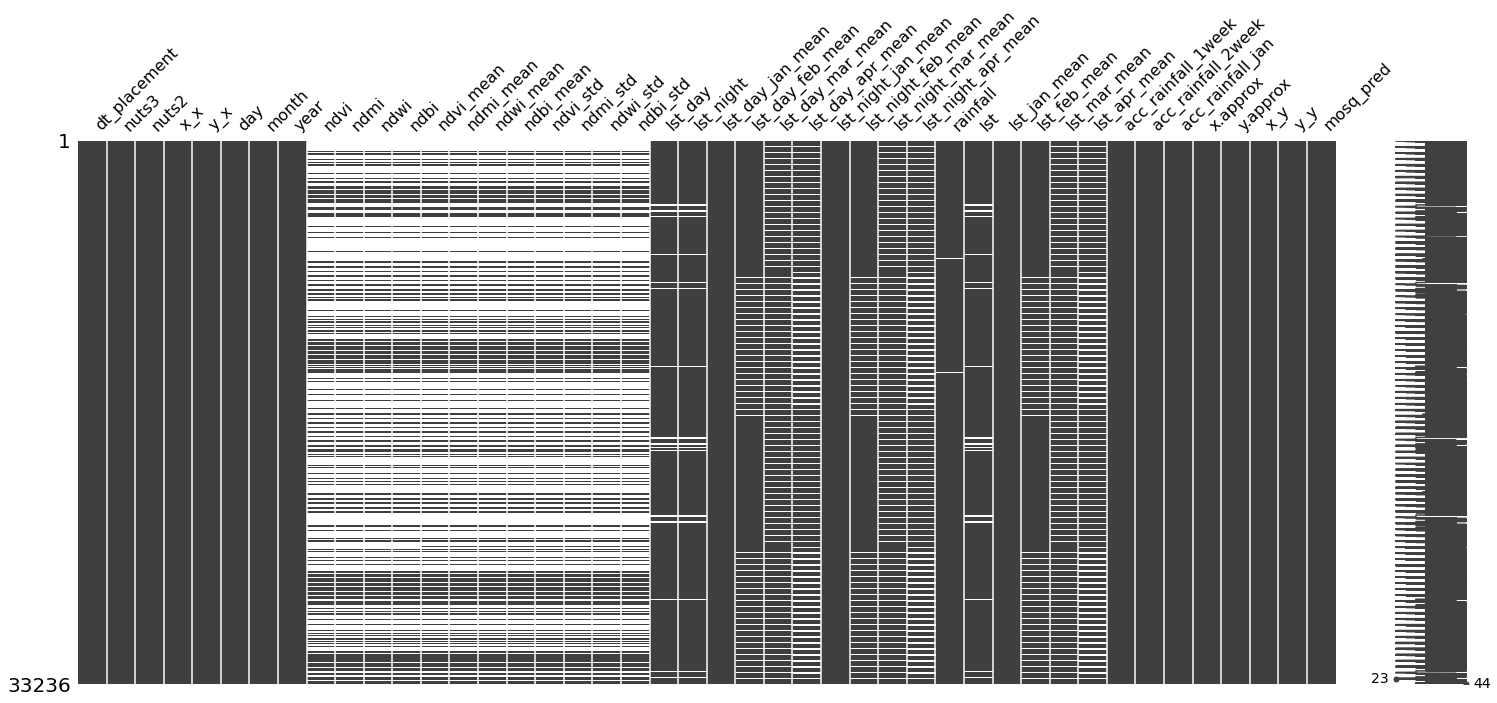

In [24]:
missingno.matrix(dataset)

In [25]:
dataset['distance'] = dataset.apply(lambda row: compute_distance(row, x1='x_x', y1 = 'y_x', x2 = 'x_y', y2 = 'y_y'), axis=1)


In [26]:
dataset.distance.max()

7.062385047625849e-10

In [27]:
dataset.drop(columns=['x.approx', 'y.approx', 'x_y', 'y_y', 'distance'], axis=1, inplace=True)
dataset.rename(columns={"x_x": "x", "y_x": "y"}, inplace=True)

In [28]:
dataset

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred
0,2010-01-01,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.261136,6.675227,11.261136,NaN,NaN,NaN,6.675227,NaN,NaN,NaN,0.406945,8.968182,8.968182,NaN,NaN,NaN,0.406945,0.406945,0.406945,29
1,2010-01-02,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.038636,6.675227,11.149886,NaN,NaN,NaN,6.675227,NaN,NaN,NaN,3.645408,8.856932,8.912557,NaN,NaN,NaN,4.052353,4.052353,4.052353,29
2,2010-01-03,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.509773,3.653636,10.936515,NaN,NaN,NaN,5.668030,NaN,NaN,NaN,0.756104,7.081705,8.302273,NaN,NaN,NaN,4.808457,4.808457,4.808457,31
3,2010-01-04,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.719318,3.653636,10.632216,NaN,NaN,NaN,5.164432,NaN,NaN,NaN,0.487891,6.686477,7.898324,NaN,NaN,NaN,5.296348,5.296348,5.296348,48
4,2010-01-05,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.719318,3.606136,10.449636,NaN,NaN,NaN,4.852773,NaN,NaN,NaN,4.758795,6.662727,7.651205,NaN,NaN,NaN,10.055143,10.055143,10.055143,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33231,2022-12-27,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,27,12,2022,0.252575,-0.037411,-0.252861,0.037411,0.220969,0.018793,-0.215178,-0.018793,0.039362,0.036678,0.029887,0.036678,11.347922,3.283766,6.835923,12.863766,14.370955,14.370955,-0.386414,1.563534,0.665170,0.665170,0.000000,7.315844,3.224755,7.213650,7.518062,7.518062,0.134849,6.721160,1089.631358,4
33232,2022-12-28,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,28,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.845844,3.135974,6.835923,12.863766,14.370955,14.370955,-0.386414,1.563534,0.665170,0.665170,0.000000,6.990909,3.224755,7.213650,7.518062,7.518062,0.134849,0.145502,1089.631358,3
33233,2022-12-29,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,29,12,2022,0.240470,-0.014906,-0.208529,0.014906,0.219209,0.020823,-0.179726,-0.020823,0.042114,0.046982,0.040525,0.046982,10.899870,3.427792,6.835923,12.863766,14.370955,14.370955,-0.386414,1.563534,0.665170,0.665170,0.000000,7.163831,3.224755,7.213650,7.518062,7.518062,-0.000000,0.143995,1089.631358,3
33234,2022-12-30,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,30,12,2022,0.240470,-0.014906,-0.208529,0.014906,0.219209,0.020823,-0.179726,-0.020823,0.042114,0.046982,0.040525,0.046982,10.317532,3.418052,6.835923,12.863766,14.370955,14.370955,-0.386414,1.563534,0.665170,0.665170,0.000000,6.867792,3.224755,7.213650,7.518062,7.518062,-0.000000,0.134849,1089.631358,3


In [29]:
bio_values = []

for region in dataset.nuts3.unique():
    for year in dataset.year.unique():
        for month in dataset.month.unique():
            filtered_df = dataset.loc[(dataset['year'] == year) & (dataset['nuts3'] == region) & (dataset['month'] == month)].copy()
            tmin = min(filtered_df['lst_day'].min(), filtered_df['lst_night'].min())
            tmax = max(filtered_df['lst_day'].max(), filtered_df['lst_night'].max())
            prec = filtered_df['rainfall'].sum()
            bio_values.append({'nuts3': region, 
                               'year': year, 
                               'month': month, 
                               'monthly_lst_min': tmin, 
                               'monthly_lst_max': tmax,
                               'monthly_acc_prec': prec})

In [30]:
bio_values_df = pd.DataFrame(bio_values)

In [31]:
dataset = pd.merge(dataset, bio_values_df, on=['nuts3', 'year', 'month'], how='left')

In [32]:
dataset

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2010-01-01,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.261136,6.675227,11.261136,NaN,NaN,NaN,6.675227,NaN,NaN,NaN,0.406945,8.968182,8.968182,NaN,NaN,NaN,0.406945,0.406945,0.406945,29,-3.823409,11.261136,81.491186
1,2010-01-02,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.038636,6.675227,11.149886,NaN,NaN,NaN,6.675227,NaN,NaN,NaN,3.645408,8.856932,8.912557,NaN,NaN,NaN,4.052353,4.052353,4.052353,29,-3.823409,11.261136,81.491186
2,2010-01-03,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.509773,3.653636,10.936515,NaN,NaN,NaN,5.668030,NaN,NaN,NaN,0.756104,7.081705,8.302273,NaN,NaN,NaN,4.808457,4.808457,4.808457,31,-3.823409,11.261136,81.491186
3,2010-01-04,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.719318,3.653636,10.632216,NaN,NaN,NaN,5.164432,NaN,NaN,NaN,0.487891,6.686477,7.898324,NaN,NaN,NaN,5.296348,5.296348,5.296348,48,-3.823409,11.261136,81.491186
4,2010-01-05,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.719318,3.606136,10.449636,NaN,NaN,NaN,4.852773,NaN,NaN,NaN,4.758795,6.662727,7.651205,NaN,NaN,NaN,10.055143,10.055143,10.055143,50,-3.823409,11.261136,81.491186
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33231,2022-12-27,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,27,12,2022,0.252575,-0.037411,-0.252861,0.037411,0.220969,0.018793,-0.215178,-0.018793,0.039362,0.036678,0.029887,0.036678,11.347922,3.283766,6.835923,12.863766,14.370955,14.370955,-0.386414,1.563534,0.665170,0.665170,0.000000,7.315844,3.224755,7.213650,7.518062,7.518062,0.134849,6.721160,1089.631358,4,-0.980130,11.946364,11.240547
33232,2022-12-28,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,28,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.845844,3.135974,6.835923,12.863766,14.370955,14.370955,-0.386414,1.563534,0.665170,0.665170,0.000000,6.990909,3.224755,7.213650,7.518062,7.518062,0.134849,0.145502,1089.631358,3,-0.980130,11.946364,11.240547
33233,2022-12-29,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,29,12,2022,0.240470,-0.014906,-0.208529,0.014906,0.219209,0.020823,-0.179726,-0.020823,0.042114,0.046982,0.040525,0.046982,10.899870,3.427792,6.835923,12.863766,14.370955,14.370955,-0.386414,1.563534,0.665170,0.665170,0.000000,7.163831,3.224755,7.213650,7.518062,7.518062,-0.000000,0.143995,1089.631358,3,-0.980130,11.946364,11.240547
33234,2022-12-30,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,30,12,2022,0.240470,-0.014906,-0.208529,0.014906,0.219209,0.020823,-0.179726,-0.020823,0.042114,0.046982,0.040525,0.046982,10.317532,3.418052,6.835923,12.863766,14.370955,14.370955,-0.386414,1.563534,0.665170,0.665170,0.000000,6.867792,3.224755,7.213650,7.518062,7.518062,-0.000000,0.134849,1089.631358,3,-0.980130,11.946364,11.240547


<AxesSubplot:>

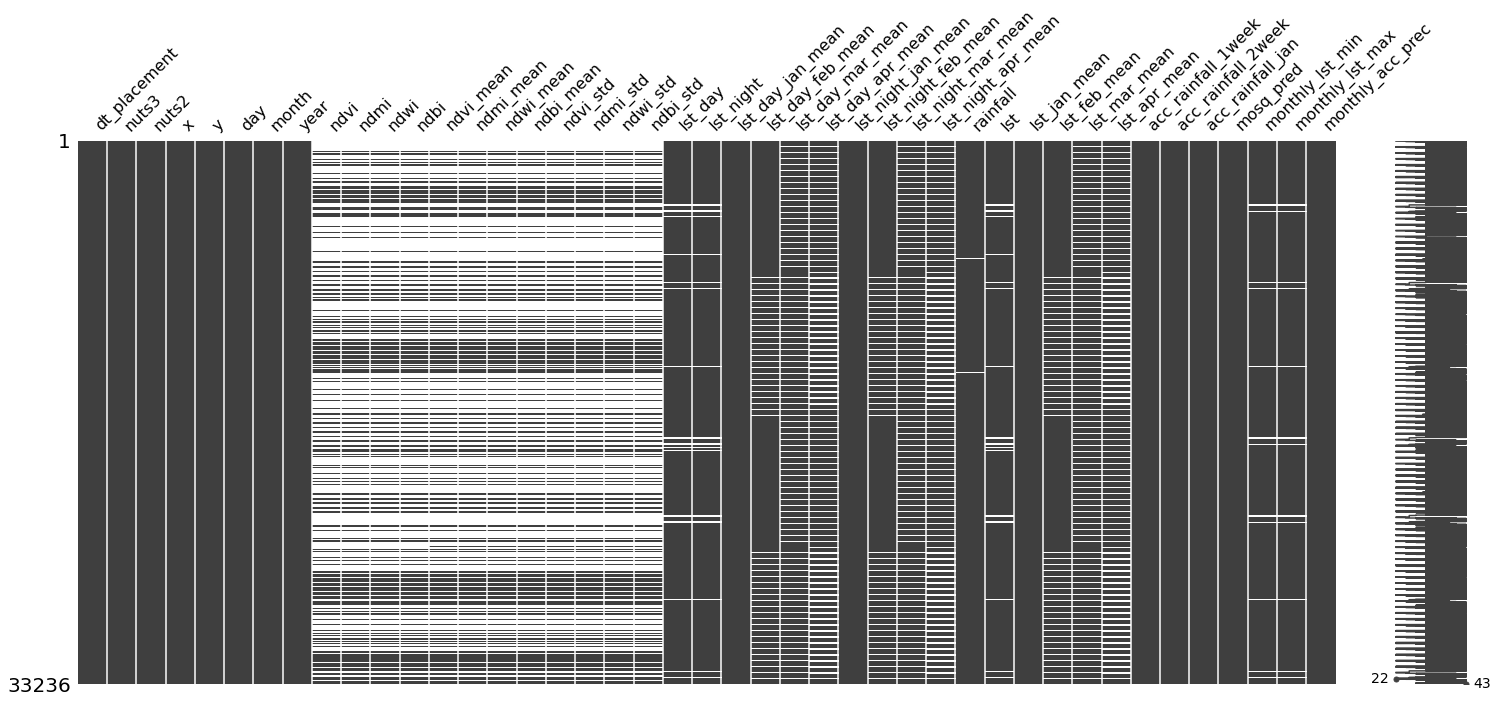

In [33]:
missingno.matrix(dataset)

In [34]:
dataset.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)

In [35]:
dataset['date_string'] = dataset['month'].astype(str) + '-' + dataset['year'].astype(str)
dataset['dt_placement'] = pd.to_datetime(dataset['date_string'], format='%m-%Y').dt.to_period('M')
dataset.drop(columns=['date_string'], inplace = True)

In [36]:
dataset

,dt_placement_daily,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec,dt_placement
0,2010-01-01,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.261136,6.675227,11.261136,NaN,NaN,NaN,6.675227,NaN,NaN,NaN,0.406945,8.968182,8.968182,NaN,NaN,NaN,0.406945,0.406945,0.406945,29,-3.823409,11.261136,81.491186,2010-01
1,2010-01-02,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.038636,6.675227,11.149886,NaN,NaN,NaN,6.675227,NaN,NaN,NaN,3.645408,8.856932,8.912557,NaN,NaN,NaN,4.052353,4.052353,4.052353,29,-3.823409,11.261136,81.491186,2010-01
2,2010-01-03,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.509773,3.653636,10.936515,NaN,NaN,NaN,5.668030,NaN,NaN,NaN,0.756104,7.081705,8.302273,NaN,NaN,NaN,4.808457,4.808457,4.808457,31,-3.823409,11.261136,81.491186,2010-01
3,2010-01-04,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.719318,3.653636,10.632216,NaN,NaN,NaN,5.164432,NaN,NaN,NaN,0.487891,6.686477,7.898324,NaN,NaN,NaN,5.296348,5.296348,5.296348,48,-3.823409,11.261136,81.491186,2010-01
4,2010-01-05,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.719318,3.606136,10.449636,NaN,NaN,NaN,4.852773,NaN,NaN,NaN,4.758795,6.662727,7.651205,NaN,NaN,NaN,10.055143,10.055143,10.055143,50,-3.823409,11.261136,81.491186,2010-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33231,2022-12-27,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,27,12,2022,0.252575,-0.037411,-0.252861,0.037411,0.220969,0.018793,-0.215178,-0.018793,0.039362,0.036678,0.029887,0.036678,11.347922,3.283766,6.835923,12.863766,14.370955,14.370955,-0.386414,1.563534,0.665170,0.665170,0.000000,7.315844,3.224755,7.213650,7.518062,7.518062,0.134849,6.721160,1089.631358,4,-0.980130,11.946364,11.240547,2022-12
33232,2022-12-28,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,28,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.845844,3.135974,6.835923,12.863766,14.370955,14.370955,-0.386414,1.563534,0.665170,0.665170,0.000000,6.990909,3.224755,7.213650,7.518062,7.518062,0.134849,0.145502,1089.631358,3,-0.980130,11.946364,11.240547,2022-12
33233,2022-12-29,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,29,12,2022,0.240470,-0.014906,-0.208529,0.014906,0.219209,0.020823,-0.179726,-0.020823,0.042114,0.046982,0.040525,0.046982,10.899870,3.427792,6.835923,12.863766,14.370955,14.370955,-0.386414,1.563534,0.665170,0.665170,0.000000,7.163831,3.224755,7.213650,7.518062,7.518062,-0.000000,0.143995,1089.631358,3,-0.980130,11.946364,11.240547,2022-12
33234,2022-12-30,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,30,12,2022,0.240470,-0.014906,-0.208529,0.014906,0.219209,0.020823,-0.179726,-0.020823,0.042114,0.046982,0.040525,0.046982,10.317532,3.418052,6.835923,12.863766,14.370955,14.370955,-0.386414,1.563534,0.665170,0.665170,0.000000,6.867792,3.224755,7.213650,7.518062,7.518062,-0.000000,0.134849,1089.631358,3,-0.980130,11.946364,11.240547,2022-12


In [37]:
grouped = dataset.groupby(['dt_placement', 'nuts3', 'nuts2'], as_index = False)
grouped_mosq = dataset.groupby(['dt_placement', 'nuts3', 'nuts2'], as_index = False)


dataset_month = grouped.mean()
dataset_month_mosq = grouped.sum()


dataset_month

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2010-01,ημαθιας,κεντρικης μακεδονιας,22.215876,40.552658,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.168909,2.702302,9.488764,NaN,NaN,NaN,4.083903,NaN,NaN,NaN,2.617253,4.443226,6.794681,NaN,NaN,NaN,15.306163,25.795942,35.973005,51.741935,-0.015091,12.092545,81.134845
1,2010-01,θεσσαλονικης,κεντρικης μακεδονιας,23.139532,40.695359,16.000000,1.000000,2010.000000,0.175493,0.071702,-0.056915,-0.071702,0.172318,0.088799,-0.032403,-0.088799,0.042514,0.054716,0.077593,0.054716,7.923406,1.710122,10.192104,NaN,NaN,NaN,3.731727,NaN,NaN,NaN,1.364895,4.816764,6.961915,NaN,NaN,NaN,7.807795,13.338001,19.783772,82.387097,-2.877717,13.860079,42.311748
2,2010-01,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,16.000000,1.000000,2010.000000,0.255218,0.018641,-0.202371,-0.018641,0.264063,-0.000393,-0.237660,0.000393,0.052228,0.059338,0.109973,0.059338,7.190461,0.340620,9.151682,NaN,NaN,NaN,2.625300,NaN,NaN,NaN,1.715277,3.765541,5.888491,NaN,NaN,NaN,9.279576,14.213017,18.993597,55.129032,-4.895934,12.183407,53.173589
3,2010-01,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.414831,0.975051,8.964341,NaN,NaN,NaN,3.623414,NaN,NaN,NaN,2.628748,3.694941,6.293877,NaN,NaN,NaN,14.713423,22.905129,32.657020,41.000000,-3.823409,11.261136,81.491186
4,2010-01,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.354315,3.828251,11.918324,NaN,NaN,NaN,5.284673,NaN,NaN,NaN,2.642814,6.091283,8.601499,NaN,NaN,NaN,15.859868,27.160592,39.731443,61.129032,1.550444,15.961111,81.927242
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1087,2022-12,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,16.000000,12.000000,2022.000000,0.248495,-0.068467,-0.235479,0.068467,0.235742,-0.051754,-0.226094,0.051754,0.043100,0.039837,0.035631,0.039837,11.139610,3.633616,8.187343,13.880495,14.817068,14.817068,-0.488093,1.139192,0.183244,0.183244,0.428564,7.386613,3.849625,7.509843,7.500156,7.500156,3.368094,7.215676,1073.761431,6.870968,-0.776374,13.218571,13.285493
1088,2022-12,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,16.000000,12.000000,2022.000000,0.361093,0.046365,-0.292366,-0.046365,0.341004,0.040693,-0.272229,-0.040693,0.046640,0.044141,0.048406,0.044141,11.136942,3.200919,8.040870,12.913580,12.829817,12.829817,-0.570395,1.041250,0.131540,0.131540,0.246525,7.168931,3.735237,6.977415,6.480678,6.480678,1.949946,4.340783,1155.499660,10.806452,-1.147727,12.883636,7.642274
1089,2022-12,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,16.000000,12.000000,2022.000000,0.348460,0.058114,-0.295928,-0.058114,0.333715,0.067023,-0.277636,-0.067023,0.053367,0.053612,0.048176,0.053612,11.967030,5.131556,8.892165,12.937206,12.690186,12.690186,0.455459,2.196651,1.193384,1.193384,0.454793,8.549293,4.673812,7.566929,6.941785,6.941785,3.536812,7.632461,1219.078173,11.967742,0.458444,13.583778,14.098596
1090,2022-12,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,16.000000,12.000000,2022.000000,0.258193,-0.037033,-0.251383,0.037033,0.246811,-0.019297,-0.236606,0.019297,0.045739,0.043301,0.038884,0.043301,10.229044,4.186004,6.835923,12.863766,14.370955,14.370955,-0.386414,1.563534,0.665170,0.665170,0.362598,7.207524,3.224755,7.213650,7.518062,7.518062,2.811723,6.023941,1085.465943,5.516129,-0.980130,11.94

In [38]:
dataset_month_mosq

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2010-01,ημαθιας,κεντρικης μακεδονιας,688.692167,1257.132387,496,31,62310,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,191.236182,83.771360,294.151693,0.000000,0.000000,0.000000,126.601002,0.000000,0.000000,0.000000,81.134845,137.739997,210.635122,0.000000,0.000000,0.000000,474.491044,799.674200,1115.163154,1604,-0.467818,374.868909,2515.180205
1,2010-01,θεσσαλονικης,κεντρικης μακεδονιας,717.325501,1261.556131,496,31,62310,0.350987,0.143404,-0.113831,-0.143404,0.344637,0.177598,-0.064807,-0.177598,0.085027,0.109432,0.155185,0.109432,245.625591,53.013780,315.955226,0.000000,0.000000,0.000000,115.683527,0.000000,0.000000,0.000000,42.311748,149.319685,215.819376,0.000000,0.000000,0.000000,242.041642,413.478029,613.296917,2554,-89.209213,429.662441,1311.664193
2,2010-01,κιλκις,κεντρικης μακεδονιας,705.517642,1271.503488,496,31,62310,0.510436,0.037281,-0.404743,-0.037281,0.528126,-0.000787,-0.475321,0.000787,0.104457,0.118675,0.219946,0.118675,222.904286,10.559231,283.702155,0.000000,0.000000,0.000000,81.384305,0.000000,0.000000,0.000000,53.173589,116.731758,182.543230,0.000000,0.000000,0.000000,287.666868,440.603526,588.801496,1709,-151.773956,377.685604,1648.381269
3,2010-01,πελλας,κεντρικης μακεδονιας,685.385175,1267.553455,496,31,62310,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,198.859773,30.226591,277.894584,0.000000,0.000000,0.000000,112.325820,0.000000,0.000000,0.000000,81.491186,114.543182,195.110202,0.000000,0.000000,0.000000,456.116114,710.059006,1012.367609,1271,-118.525682,349.095227,2526.226756
4,2010-01,πιεριας,κεντρικης μακεδονιας,695.684730,1248.362181,496,31,62310,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,258.983778,118.675778,369.468055,0.000000,0.000000,0.000000,163.824856,0.000000,0.000000,0.000000,81.927242,188.829778,266.646456,0.000000,0.000000,0.000000,491.655897,841.978348,1231.674728,1895,48.063778,494.794444,2539.744488
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1087,2022-12,κιλκις,κεντρικης μακεδονιας,705.517642,1271.503488,496,372,62682,2.981937,-0.821599,-2.825748,0.821599,2.828903,-0.621047,-2.713128,0.621047,0.517202,0.478045,0.427570,0.478045,245.071429,79.939560,253.807643,430.295330,459.329121,459.329121,-15.130879,35.314937,5.680549,5.680549,13.285493,162.505495,119.338382,232.805133,232.504835,232.504835,104.410907,223.685941,33286.604352,213,-24.067582,409.775714,411.850279
1088,2022-12,πελλας,κεντρικης μακεδονιας,685.385175,1267.553455,496,372,62682,8.305140,1.066398,-6.724425,-1.066398,7.843088,0.935928,-6.261263,-0.935928,1.072721,1.015235,1.113340,1.015235,245.012727,70.420227,249.266978,400.320966,397.724318,397.724318,-17.682258,32.278750,4.077727,4.077727,7.642274,157.716477,115.792360,216.299858,200.901023,200.901023,60.448311,134.564280,35820.489475,335,-35.579545,399.392727,236.910505
1089,2022-12,πιεριας,κεντρικης μακεδονιας,695.684730,1248.362181,496,372,62682,8.014569,1.336613,-6.806355,-1.336613,7.675447,1.541534,-6.385621,-1.541534,1.227432,1.233086,1.108056,1.233086,263.274667,112.894222,275.657111,401.053397,393.395778,393.395778,14.119244,68.096175,36.994889,36.994889,14.098596,188.084444,144.888178,234.574786,215.195333,215.195333,109.641164,236.606286,37791.423353,371,14.211778,42

In [39]:
dataset_month['mosq_pred'] = dataset_month_mosq['mosq_pred']

In [40]:
wnv_file.head(5)

,nuts2,nuts3,dt_placement,cases
0,κεντρικης μακεδονιας,ημαθιας,2010-06,0
1,κεντρικης μακεδονιας,ημαθιας,2010-07,6
2,κεντρικης μακεδονιας,ημαθιας,2010-08,36
3,κεντρικης μακεδονιας,ημαθιας,2010-09,7
4,κεντρικης μακεδονιας,ημαθιας,2010-10,0


In [41]:
dataset_month.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1092 entries, 0 to 1091
Data columns (total 43 columns):
 #   Column              Non-Null Count  Dtype    
---  ------              --------------  -----    
 0   dt_placement        1092 non-null   period[M]
 1   nuts3               1092 non-null   object   
 2   nuts2               1092 non-null   object   
 3   x                   1092 non-null   float64  
 4   y                   1092 non-null   float64  
 5   day                 1092 non-null   float64  
 6   month               1092 non-null   float64  
 7   year                1092 non-null   float64  
 8   ndvi                1035 non-null   float64  
 9   ndmi                1035 non-null   float64  
 10  ndwi                1035 non-null   float64  
 11  ndbi                1035 non-null   float64  
 12  ndvi_mean           1036 non-null   float64  
 13  ndmi_mean           1036 non-null   float64  
 14  ndwi_mean           1036 non-null   float64  
 15  ndbi_mean           1

In [42]:
wnv_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378 entries, 0 to 377
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   nuts2         378 non-null    object
 1   nuts3         378 non-null    object
 2   dt_placement  378 non-null    object
 3   cases         378 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 11.9+ KB


In [43]:
wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [44]:
wnv_file

,nuts2,nuts3,dt_placement,cases
0,κεντρικης μακεδονιας,ημαθιας,2010-06,0
1,κεντρικης μακεδονιας,ημαθιας,2010-07,6
2,κεντρικης μακεδονιας,ημαθιας,2010-08,36
3,κεντρικης μακεδονιας,ημαθιας,2010-09,7
4,κεντρικης μακεδονιας,ημαθιας,2010-10,0
...,...,...,...,...
373,κεντρικης μακεδονιας,χαλκιδικης,2022-07,0
374,κεντρικης μακεδονιας,χαλκιδικης,2022-08,12
375,κεντρικης μακεδονιας,χαλκιδικης,2022-09,10
376,κεντρικης μακεδονιας,χαλκιδικης,2022-10,1


In [45]:
wnv_file['cases'].value_counts()

0     240
1      39
2      22
3      17
4      10
5       8
11      5
6       5
10      5
7       5
12      4
13      3
8       2
17      2
20      2
16      1
9       1
41      1
27      1
49      1
40      1
50      1
36      1
34      1
Name: cases, dtype: int64

In [46]:
wnv_file.cases.sum()

863

In [47]:
merged = dataset_month.merge(wnv_file, how='left', on=['dt_placement', 'nuts3', 'nuts2'] )

In [48]:
merged

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases
0,2010-01,ημαθιας,κεντρικης μακεδονιας,22.215876,40.552658,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.168909,2.702302,9.488764,NaN,NaN,NaN,4.083903,NaN,NaN,NaN,2.617253,4.443226,6.794681,NaN,NaN,NaN,15.306163,25.795942,35.973005,1604,-0.015091,12.092545,81.134845,NaN
1,2010-01,θεσσαλονικης,κεντρικης μακεδονιας,23.139532,40.695359,16.000000,1.000000,2010.000000,0.175493,0.071702,-0.056915,-0.071702,0.172318,0.088799,-0.032403,-0.088799,0.042514,0.054716,0.077593,0.054716,7.923406,1.710122,10.192104,NaN,NaN,NaN,3.731727,NaN,NaN,NaN,1.364895,4.816764,6.961915,NaN,NaN,NaN,7.807795,13.338001,19.783772,2554,-2.877717,13.860079,42.311748,NaN
2,2010-01,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,16.000000,1.000000,2010.000000,0.255218,0.018641,-0.202371,-0.018641,0.264063,-0.000393,-0.237660,0.000393,0.052228,0.059338,0.109973,0.059338,7.190461,0.340620,9.151682,NaN,NaN,NaN,2.625300,NaN,NaN,NaN,1.715277,3.765541,5.888491,NaN,NaN,NaN,9.279576,14.213017,18.993597,1709,-4.895934,12.183407,53.173589,NaN
3,2010-01,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.414831,0.975051,8.964341,NaN,NaN,NaN,3.623414,NaN,NaN,NaN,2.628748,3.694941,6.293877,NaN,NaN,NaN,14.713423,22.905129,32.657020,1271,-3.823409,11.261136,81.491186,NaN
4,2010-01,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.354315,3.828251,11.918324,NaN,NaN,NaN,5.284673,NaN,NaN,NaN,2.642814,6.091283,8.601499,NaN,NaN,NaN,15.859868,27.160592,39.731443,1895,1.550444,15.961111,81.927242,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1087,2022-12,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,16.000000,12.000000,2022.000000,0.248495,-0.068467,-0.235479,0.068467,0.235742,-0.051754,-0.226094,0.051754,0.043100,0.039837,0.035631,0.039837,11.139610,3.633616,8.187343,13.880495,14.817068,14.817068,-0.488093,1.139192,0.183244,0.183244,0.428564,7.386613,3.849625,7.509843,7.500156,7.500156,3.368094,7.215676,1073.761431,213,-0.776374,13.218571,13.285493,NaN
1088,2022-12,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,16.000000,12.000000,2022.000000,0.361093,0.046365,-0.292366,-0.046365,0.341004,0.040693,-0.272229,-0.040693,0.046640,0.044141,0.048406,0.044141,11.136942,3.200919,8.040870,12.913580,12.829817,12.829817,-0.570395,1.041250,0.131540,0.131540,0.246525,7.168931,3.735237,6.977415,6.480678,6.480678,1.949946,4.340783,1155.499660,335,-1.147727,12.883636,7.642274,NaN
1089,2022-12,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,16.000000,12.000000,2022.000000,0.348460,0.058114,-0.295928,-0.058114,0.333715,0.067023,-0.277636,-0.067023,0.053367,0.053612,0.048176,0.053612,11.967030,5.131556,8.892165,12.937206,12.690186,12.690186,0.455459,2.196651,1.193384,1.193384,0.454793,8.549293,4.673812,7.566929,6.941785,6.941785,3.536812,7.632461,1219.078173,371,0.458444,13.583778,14.098596,NaN
1090,2022-12,σερρων,κεντρικης μακεδονιας,23.542098,41.085750,16.000000,12.000000,2022.000000,0.258193,-0.037033,-0.251383,0.037033,0.246811,-0.019297,-0.236606,0.019297,0.045739,0.043301,0.038884,0.043301,10.229044,4.186004,6.835923,12.863766,14.370955,14.370955,-0.386414,1.563534,0.665170,0.665170,0.362598,7.207524,3.224755,7.213650,7.518062,7.518062,2.811723,6.023941,1085.465943,171,-0.980130,11.946364,

In [49]:
merged = fillna(merged,{'cases': 0})

In [50]:
merged['cases'].value_counts()

0.000000     954
1.000000      39
2.000000      22
3.000000      17
4.000000      10
5.000000       8
10.000000      5
11.000000      5
7.000000       5
6.000000       5
12.000000      4
13.000000      3
17.000000      2
8.000000       2
20.000000      2
50.000000      1
9.000000       1
16.000000      1
41.000000      1
34.000000      1
27.000000      1
40.000000      1
49.000000      1
36.000000      1
Name: cases, dtype: int64

In [51]:
merged.cases.sum()

863.0

In [52]:
merged = merged.astype({'day':'int', 'month':'int', 'year':'int', 'cases': 'int'})

In [53]:
merged.drop(columns=['day'], inplace=True)

<AxesSubplot:>

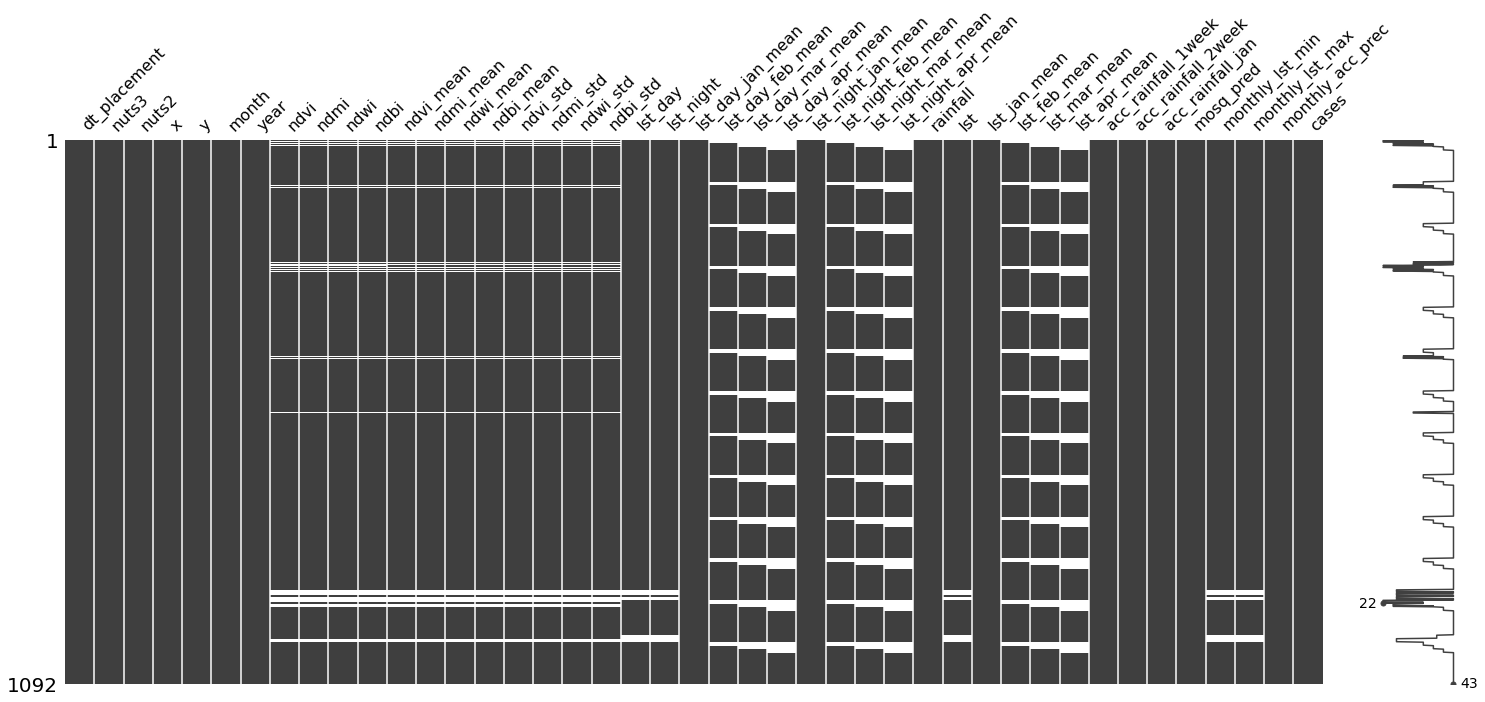

In [54]:
missingno.matrix(merged)

In [55]:
missing = describe_dataframe(merged)
missing

,Column,Missing
0,dt_placement,0.000000
1,nuts3,0.000000
2,nuts2,0.000000
3,x,0.000000
4,y,0.000000
5,month,0.000000
6,year,0.000000
7,ndvi,5.219800
8,ndmi,5.219800
9,ndwi,5.219800


In [56]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'monthly_lst_min', 'monthly_lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['monthly_lst_min', 'monthly_lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

In [57]:
missing = describe_dataframe(merged)
missing

,Column,Missing
0,dt_placement,0.000000
1,nuts3,0.000000
2,nuts2,0.000000
3,x,0.000000
4,y,0.000000
5,month,0.000000
6,year,0.000000
7,ndvi,5.219800
8,ndmi,5.219800
9,ndwi,5.219800


In [58]:
years = merged.year.unique()
years

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022])

In [59]:
nuts3_units = merged.nuts3.unique()
nuts3_units

array(['ημαθιας', 'θεσσαλονικης', 'κιλκις', 'πελλας', 'πιεριας', 'σερρων',
       'χαλκιδικης'], dtype=object)

In [60]:
rows = []
for year in years:
    for region in nuts3_units:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['nuts3'] == region)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['monthly_lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['monthly_lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['monthly_acc_prec'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'nuts3': region, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [61]:
biovars_df.head(20)

,nuts3,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,ημαθιας,2010,14.583333,18.666667,49.122807,768.952455,34.000000,-4.000000,38.000000,9.166667,23.833333,23.833333,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000
1,θεσσαλονικης,2010,16.125000,20.083333,46.705426,865.533204,39.000000,-4.000000,43.000000,10.333333,26.166667,26.500000,5.333333,1341.000000,362.000000,8.000000,88.115950,512.000000,157.000000,210.000000,391.000000
2,κιλκις,2010,16.083333,21.500000,46.739130,890.054476,41.000000,-5.000000,46.000000,9.833333,26.166667,27.000000,5.000000,1417.000000,379.000000,10.000000,78.775725,584.000000,198.000000,223.000000,377.000000
3,πελλας,2010,14.750000,19.166667,47.916667,790.425662,36.000000,-4.000000,40.000000,9.333333,24.500000,24.500000,4.666667,1630.000000,348.000000,19.000000,63.316479,629.000000,219.000000,219.000000,490.000000
4,πιεριας,2010,15.916667,18.333333,45.833333,769.247960,37.000000,-3.000000,40.000000,15.666667,25.500000,25.500000,6.500000,1470.000000,325.000000,27.000000,70.741701,556.000000,174.000000,174.000000,437.000000
5,σερρων,2010,15.750000,19.833333,45.075758,882.274952,39.000000,-5.000000,44.000000,9.833333,25.666667,26.166667,4.500000,1423.000000,319.000000,11.000000,73.019474,505.000000,173.000000,270.000000,446.000000
6,χαλκιδικης,2010,16.083333,17.833333,45.726496,746.151743,37.000000,-2.000000,39.000000,11.333333,25.166667,25.333333,7.166667,1379.000000,385.000000,5.000000,93.001363,529.000000,168.000000,214.000000,430.000000
7,ημαθιας,2011,13.916667,19.500000,48.750000,802.222292,35.000000,-5.000000,40.000000,13.666667,23.666667,23.666667,4.500000,874.000000,148.000000,14.000000,49.642554,296.000000,108.000000,108.000000,257.000000
8,θεσσαλονικης,2011,15.166667,20.833333,49.603175,884.033456,38.000000,-4.000000,42.000000,13.500000,26.000000,26.333333,5.166667,876.000000,143.000000,19.000000,56.510522,283.000000,113.000000,205.000000,234.000000
9,κιλκις,2011,15.208333,23.416667,45.915033,943.267612,40.000000,-11.000000,51.000000,12.833333,26.666667,27.166667,4.833333,798.000000,151.000000,5.000000,65.470755,265.000000,128.000000,195.000000,193.000000


In [62]:
merged = pd.merge(merged, biovars_df,  how='left', on=['nuts3', 'year'])

In [63]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2010) & (merged['nuts3'] == 'ημαθιας')]

,dt_placement,nuts3,nuts2,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2010-01,ημαθιας,κεντρικης μακεδονιας,22.215876,40.552658,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.168909,2.702302,9.488764,NaN,NaN,NaN,4.083903,NaN,NaN,NaN,2.617253,4.443226,6.794681,NaN,NaN,NaN,15.306163,25.795942,35.973005,1604,-0.015091,12.092545,81.134845,0,14.583333,18.666667,49.122807,768.952455,34.000000,-4.000000,38.000000,9.166667,23.833333,23.833333,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000
7,2010-02,ημαθιας,κεντρικης μακεδονιας,22.215876,40.552658,2,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.736428,1.371205,6.168909,4.651637,NaN,NaN,2.664997,-0.644107,NaN,NaN,10.208667,4.359364,4.416953,2.318399,NaN,NaN,71.780864,142.317966,247.123971,841,-4.002083,11.714000,285.842680,0,14.583333,18.666667,49.122807,768.952455,34.000000,-4.000000,38.000000,9.166667,23.833333,23.833333,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000
14,2010-03,ημαθιας,κεντρικης μακεδονιας,22.215876,40.552658,3,2010,0.306789,0.153101,-0.138970,-0.153101,0.299181,0.139387,-0.144685,-0.139387,0.042870,0.046756,0.048620,0.046756,15.908721,3.687326,6.168909,6.736824,15.059269,NaN,2.664997,1.525188,3.558160,NaN,3.788843,9.798023,4.416953,4.131006,9.308714,NaN,28.648361,56.408068,437.915193,953,0.445636,21.507455,117.454131,0,14.583333,18.666667,49.122807,768.952455,34.000000,-4.000000,38.000000,9.166667,23.833333,23.833333,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000
21,2010-04,ημαθιας,κεντρικης μακεδονιας,22.215876,40.552658,4,2010,0.406513,0.144527,-0.232916,-0.144527,0.417933,0.143252,-0.242450,-0.143252,0.042646,0.045180,0.040471,0.045180,22.364242,7.348303,6.168909,6.736824,15.908721,22.573057,2.664997,1.525188,3.687326,6.590470,2.476825,14.856273,4.416953,4.131006,9.798023,14.581764,17.905755,37.747035,517.210047,1583,4.902364,27.275455,74.304749,0,14.583333,18.666667,49.122807,768.952455,34.000000,-4.000000,38.000000,9.166667,23.833333,23.833333,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000
28,2010-05,ημαθιας,κεντρικης μακεδονιας,22.215876,40.552658,5,2010,0.553118,0.207209,-0.325464,-0.207209,0.534235,0.195843,-0.319145,-0.195843,0.055996,0.051456,0.034650,0.051456,27.508698,13.070774,6.168909,6.736824,15.908721,15.908721,2.664997,1.525188,3.687326,3.687326,3.953829,20.289736,4.416953,4.131006,9.798023,9.798023,25.573667,49.924291,613.462381,2433,9.828182,31.784182,122.568711,0,14.583333,18.666667,49.122807,768.952455,34.000000,-4.000000,38.000000,9.166667,23.833333,23.833333,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000
35,2010-06,ημαθιας,κεντρικης μακεδονιας,22.215876,40.552658,6,2010,0.602921,0.230007,-0.360372,-0.230007,0.597983,0.228508,-0.355233,-0.228508,0.058274,0.048741,0.026554,0.048741,29.311794,16.396752,6.168909,6.736824,15.908721,15.908721,2.664997,1.525188,3.687326,3.687326,3.256906,22.854273,4.416953,4.131006,9.798023,9.798023,24.035278,49.956191,736.845103,2055,13.093273,33.622727,97.707186,0,14.583333,18.666667,49.122807,768.952455,34.000000,-4.000000,38.000000,9.166667,23.833333,23.833333,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000
42,2010-07,ημαθιας,κεντρικης μακεδονιας,22.215876,40.552658,7,2010,0.593160,0.237814,-0.3429

In [64]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [65]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [66]:
# df_demographics_nuts2 = df_demographics.query(f"nuts2 == '{NUTS2_EL}'").copy()
df_demographics_nuts2 = df_demographics.query(f"NUTS3_CODE.str.startswith('EL52')").copy()

In [67]:
code_to_name = {
    'EL521': 'ημαθιας',
    'EL522': 'θεσσαλονικης',
    'EL523': 'κιλκις',
    'EL524': 'πελλας',
    'EL525': 'πιεριας',
    'EL526': 'σερρων',
    'EL527': 'χαλκιδικης'
}

df_demographics_nuts2['NUTS3_NAME'] = df_demographics_nuts2['NUTS3_CODE'].map(code_to_name)

In [68]:
# df_demographics_nuts2.drop(columns=['nuts2', 'nuts3'], inplace=True)
df_demographics_nuts2.drop(columns=['NUTS3_CODE'], inplace=True)
df_demographics_nuts2.reset_index(inplace=True, drop=True)
df_demographics_nuts2.rename(columns={'NUTS3_NAME': 'nuts3', 'YEAR': 'year'}, inplace=True)

In [69]:
df_demographics_nuts2

,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,nuts3
0,1991,14806.000000,46909.000000,6931.000000,68646.000000,14017.000000,47825.000000,8438.000000,70280.000000,ημαθιας
1,1992,14246.000000,47131.000000,7225.000000,68602.000000,13469.000000,47787.000000,8705.000000,69961.000000,ημαθιας
2,1993,13788.000000,47587.000000,7494.000000,68869.000000,13007.000000,48018.000000,9004.000000,70029.000000,ημαθιας
3,1994,13299.000000,47838.000000,7841.000000,68978.000000,12575.000000,48064.000000,9368.000000,70007.000000,ημαθιας
4,1995,12800.000000,47871.000000,8178.000000,68849.000000,12130.000000,48007.000000,9686.000000,69823.000000,ημαθιας
...,...,...,...,...,...,...,...,...,...,...
219,2018,8221.000000,34856.000000,12433.000000,55510.000000,7846.000000,33852.000000,13379.000000,55077.000000,χαλκιδικης
220,2019,8027.000000,34838.000000,12589.000000,55454.000000,7727.000000,33834.000000,13578.000000,55139.000000,χαλκιδικης
221,2020,7900.000000,34760.000000,12776.000000,55436.000000,7554.000000,33835.000000,13764.000000,55153.000000,χαλκιδικης
222,2021,7725.000000,34568.000000,12921.000000,55214.000000,7408.000000,33800.000000,13851.000000,55059.000000,χαλκιδικης


In [70]:
names_from_merged = merged["nuts3"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["nuts3"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [71]:
# df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('ηρωικης πολεως ναουσας','ναουσας'))


In [72]:
# names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
# names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
# diff = []

# for element in names_from_merged:
#     if element not in names_from_demographics:
#         diff.append(element)
        

# print(f"{diff}\n\nLength: {len(diff)}")

In [73]:
dataset = pd.merge(merged, df_demographics_nuts2,  how='left', on=['nuts3', 'year'])

<AxesSubplot:>

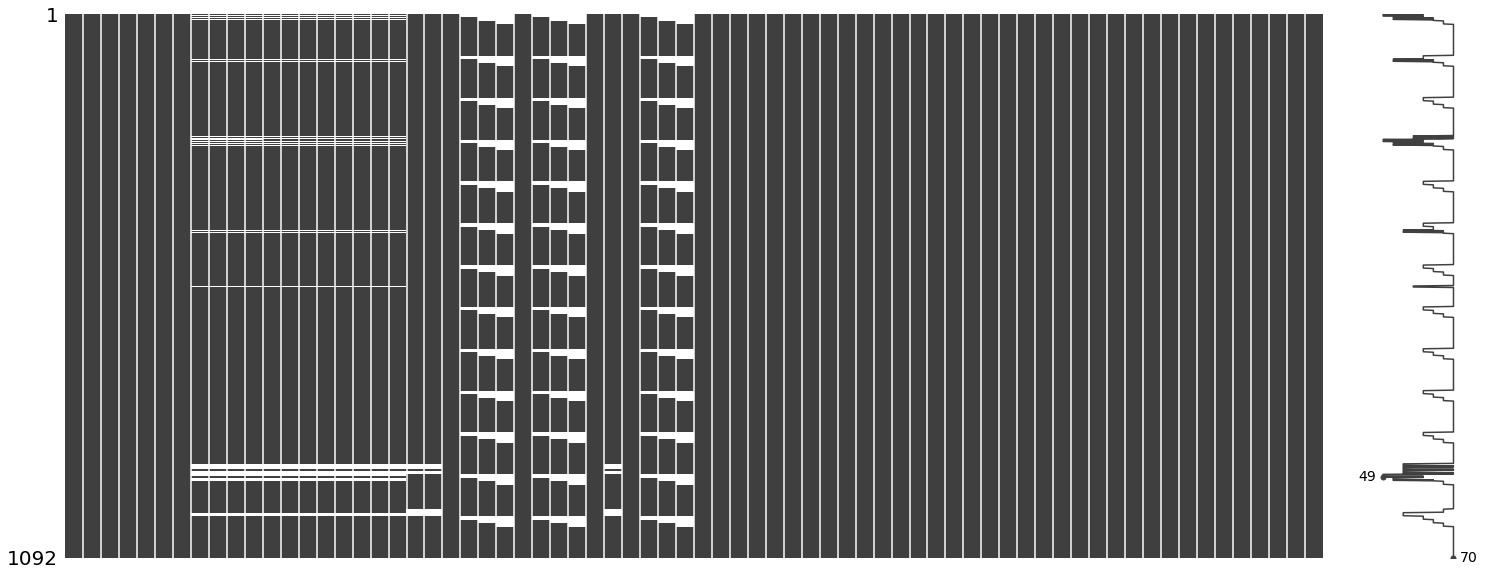

In [74]:
missingno.matrix(dataset)

In [75]:
df_economics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [76]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [77]:
df_economics_nuts2 = df_economics.query(f"NUTS3_CODE.str.startswith('EL52')").copy()

In [78]:
df_economics_nuts2['NUTS3_NAME'] = df_economics_nuts2['NUTS3_CODE'].map(code_to_name)
df_economics_nuts2.drop(columns=['NUTS3_CODE'], inplace=True)
df_economics_nuts2.reset_index(inplace=True, drop=True)
df_economics_nuts2.rename(columns={'NUTS3_NAME': 'nuts3', 'YEAR': 'year'}, inplace=True)

In [79]:
df_economics_nuts2

,year,MIO_EUR,nuts3
0,2000,1467.800000,ημαθιας
1,2001,1576.300000,ημαθιας
2,2002,1614.200000,ημαθιας
3,2003,1690.930000,ημαθιας
4,2004,1806.780000,ημαθιας
...,...,...,...
142,2016,1457.490000,χαλκιδικης
143,2017,1470.520000,χαλκιδικης
144,2018,1521.240000,χαλκιδικης
145,2019,1529.360000,χαλκιδικης


In [80]:
names_from_merged = dataset["nuts3"].drop_duplicates().sort_values().tolist()
names_from_economics = df_demographics_nuts2["nuts3"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_economics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [81]:
dataset = pd.merge(dataset, df_economics_nuts2,  how='left', on=['nuts3', 'year'])

<AxesSubplot:>

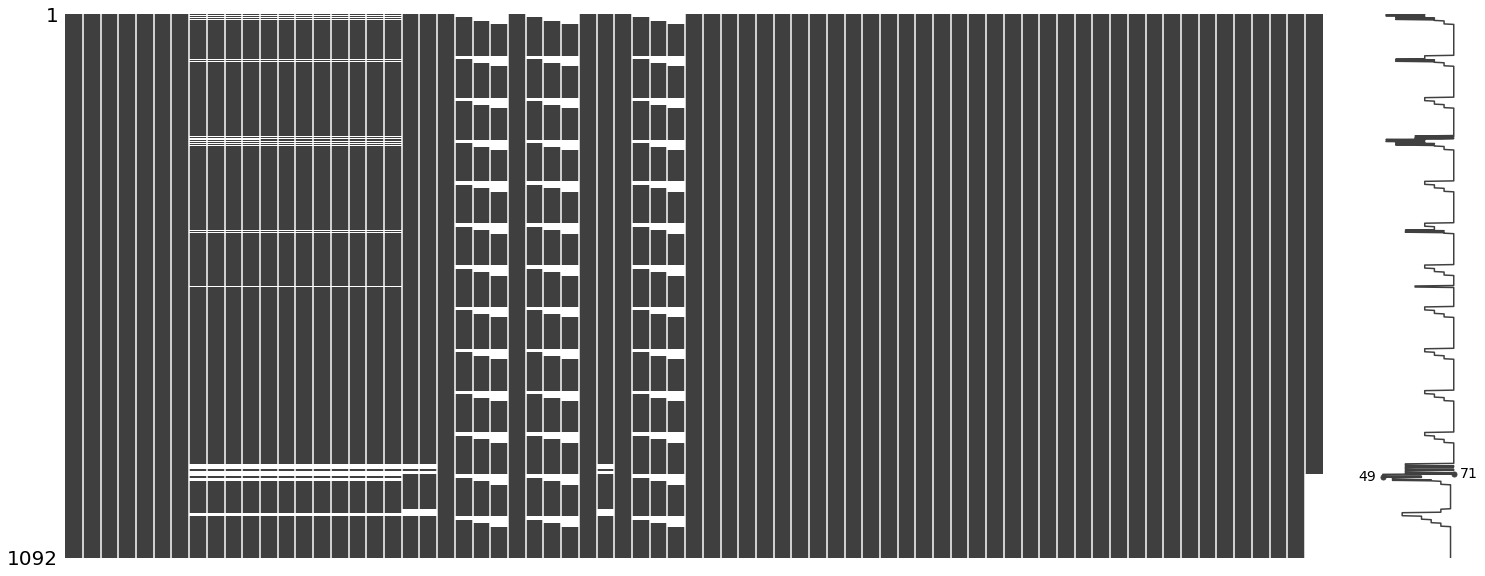

In [82]:
missingno.matrix(dataset)

In [83]:
df_trade = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [84]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [85]:
df_trade_nuts2 = df_trade.query(f"NUTS3_CODE.str.startswith('EL52')").copy()

In [86]:
df_trade_nuts2['NUTS3_NAME'] = df_trade_nuts2['NUTS3_CODE'].map(code_to_name)
df_trade_nuts2.drop(columns=['NUTS3_CODE'], inplace=True)
df_trade_nuts2.reset_index(inplace=True, drop=True)
df_trade_nuts2.rename(columns={'NUTS3_NAME': 'nuts3', 'YEAR': 'year'}, inplace=True)

In [87]:
df_trade_nuts2

,year,L_TOTAL,UNL_TOTAL,nuts3
0,2015,4287.000000,4163.000000,ημαθιας
1,2016,3098.000000,4223.000000,ημαθιας
2,2017,1714.000000,2015.000000,ημαθιας
3,2018,1790.000000,1892.000000,ημαθιας
4,2019,1884.000000,2164.000000,ημαθιας
5,2020,1662.000000,1901.000000,ημαθιας
6,2021,1706.000000,2112.000000,ημαθιας
7,2015,13373.000000,15210.000000,θεσσαλονικης
8,2016,25046.000000,26693.000000,θεσσαλονικης
9,2017,21952.000000,20502.000000,θεσσαλονικης


In [88]:
names_from_merged = dataset["nuts3"].drop_duplicates().sort_values().tolist()
names_from_economics = df_trade_nuts2["nuts3"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_economics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [89]:
dataset = pd.merge(dataset, df_trade_nuts2,  how='left', on=['nuts3', 'year'])

<AxesSubplot:>

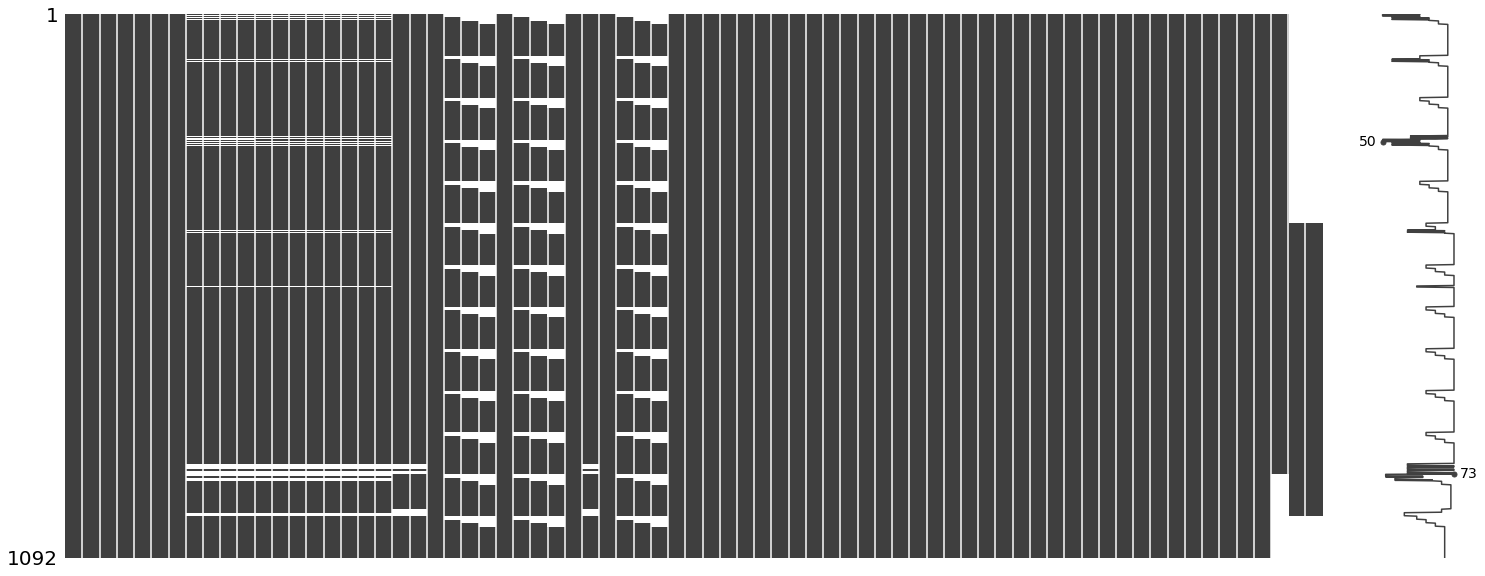

In [90]:
missingno.matrix(dataset)

In [91]:
missing = describe_dataframe(dataset)

In [92]:
missing

,Column,Missing
0,dt_placement,0.000000
1,nuts3,0.000000
2,nuts2,0.000000
3,x,0.000000
4,y,0.000000
5,month,0.000000
6,year,0.000000
7,ndvi,5.219800
8,ndmi,5.219800
9,ndwi,5.219800


In [93]:
dataset

,dt_placement,nuts3,nuts2,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2010-01,ημαθιας,κεντρικης μακεδονιας,22.215876,40.552658,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.168909,2.702302,9.488764,NaN,NaN,NaN,4.083903,NaN,NaN,NaN,2.617253,4.443226,6.794681,NaN,NaN,NaN,15.306163,25.795942,35.973005,1604,-0.015091,12.092545,81.134845,0,14.583333,18.666667,49.122807,768.952455,34.000000,-4.000000,38.000000,9.166667,23.833333,23.833333,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000,11806.000000,44835.000000,13866.000000,70507.000000,11360.000000,44584.000000,16384.000000,72328.000000,2016.250000,NaN,NaN
1,2010-01,θεσσαλονικης,κεντρικης μακεδονιας,23.139532,40.695359,1,2010,0.175493,0.071702,-0.056915,-0.071702,0.172318,0.088799,-0.032403,-0.088799,0.042514,0.054716,0.077593,0.054716,7.923406,1.710122,10.192104,NaN,NaN,NaN,3.731727,NaN,NaN,NaN,1.364895,4.816764,6.961915,NaN,NaN,NaN,7.807795,13.338001,19.783772,2554,-2.877717,13.860079,42.311748,0,16.125000,20.083333,46.705426,865.533204,39.000000,-4.000000,43.000000,10.333333,26.166667,26.500000,5.333333,1341.000000,362.000000,8.000000,88.115950,512.000000,157.000000,210.000000,391.000000,87330.000000,375115.000000,82051.000000,544496.000000,84172.000000,402246.000000,107376.000000,593794.000000,19627.510000,NaN,NaN
2,2010-01,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,1,2010,0.255218,0.018641,-0.202371,-0.018641,0.264063,-0.000393,-0.237660,0.000393,0.052228,0.059338,0.109973,0.059338,7.190461,0.340620,9.151682,NaN,NaN,NaN,2.625300,NaN,NaN,NaN,1.715277,3.765541,5.888491,NaN,NaN,NaN,9.279576,14.213017,18.993597,1709,-4.895934,12.183407,53.173589,0,16.083333,21.500000,46.739130,890.054476,41.000000,-5.000000,46.000000,9.833333,26.166667,27.000000,5.000000,1417.000000,379.000000,10.000000,78.775725,584.000000,198.000000,223.000000,377.000000,5963.000000,24603.000000,9769.000000,40335.000000,5680.000000,23436.000000,11889.000000,41005.000000,1124.520000,NaN,NaN
3,2010-01,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.414831,0.975051,8.964341,NaN,NaN,NaN,3.623414,NaN,NaN,NaN,2.628748,3.694941,6.293877,NaN,NaN,NaN,14.713423,22.905129,32.657020,1271,-3.823409,11.261136,81.491186,0,14.750000,19.166667,47.916667,790.425662,36.000000,-4.000000,40.000000,9.333333,24.500000,24.500000,4.666667,1630.000000,348.000000,19.000000,63.316479,629.000000,219.000000,219.000000,490.000000,11159.000000,44537.000000,14694.000000,70390.000000,11052.000000,43212.000000,17690.000000,71954.000000,1938.340000,NaN,NaN
4,2010-01,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.354315,3.828251,11.918324,NaN,NaN,NaN,5.284673,NaN,NaN,NaN,2.642814,6.091283,8.601499,NaN,NaN,NaN,15.859868,27.160592,39.731443,1895,1.550444,15.961111,81.927242,0,15.916667,18.333333,45.833333,769.247960,37.000000,-3.000000,40.000000,15.666667,25.500000,25.500000,6.500000,1470.000000,325.000000,27.000000,70.741701,556.000000,174.000000,174.000000,437.000000,10433.000000,40170.000000,12062.000000,62665.000000,10152.000000,40273.000000,14620.000000,65045.000000,1725.030000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [94]:
dataset.reset_index(inplace=True, drop=True)

In [95]:
dataset['cases'].value_counts()

0     954
1      39
2      22
3      17
4      10
5       8
10      5
11      5
7       5
6       5
12      4
13      3
17      2
8       2
20      2
50      1
9       1
16      1
41      1
34      1
27      1
40      1
49      1
36      1
Name: cases, dtype: int64

In [96]:
dataset['cases'].sum()

863

In [97]:
dataset

,dt_placement,nuts3,nuts2,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2010-01,ημαθιας,κεντρικης μακεδονιας,22.215876,40.552658,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.168909,2.702302,9.488764,NaN,NaN,NaN,4.083903,NaN,NaN,NaN,2.617253,4.443226,6.794681,NaN,NaN,NaN,15.306163,25.795942,35.973005,1604,-0.015091,12.092545,81.134845,0,14.583333,18.666667,49.122807,768.952455,34.000000,-4.000000,38.000000,9.166667,23.833333,23.833333,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000,11806.000000,44835.000000,13866.000000,70507.000000,11360.000000,44584.000000,16384.000000,72328.000000,2016.250000,NaN,NaN
1,2010-01,θεσσαλονικης,κεντρικης μακεδονιας,23.139532,40.695359,1,2010,0.175493,0.071702,-0.056915,-0.071702,0.172318,0.088799,-0.032403,-0.088799,0.042514,0.054716,0.077593,0.054716,7.923406,1.710122,10.192104,NaN,NaN,NaN,3.731727,NaN,NaN,NaN,1.364895,4.816764,6.961915,NaN,NaN,NaN,7.807795,13.338001,19.783772,2554,-2.877717,13.860079,42.311748,0,16.125000,20.083333,46.705426,865.533204,39.000000,-4.000000,43.000000,10.333333,26.166667,26.500000,5.333333,1341.000000,362.000000,8.000000,88.115950,512.000000,157.000000,210.000000,391.000000,87330.000000,375115.000000,82051.000000,544496.000000,84172.000000,402246.000000,107376.000000,593794.000000,19627.510000,NaN,NaN
2,2010-01,κιλκις,κεντρικης μακεδονιας,22.758634,41.016242,1,2010,0.255218,0.018641,-0.202371,-0.018641,0.264063,-0.000393,-0.237660,0.000393,0.052228,0.059338,0.109973,0.059338,7.190461,0.340620,9.151682,NaN,NaN,NaN,2.625300,NaN,NaN,NaN,1.715277,3.765541,5.888491,NaN,NaN,NaN,9.279576,14.213017,18.993597,1709,-4.895934,12.183407,53.173589,0,16.083333,21.500000,46.739130,890.054476,41.000000,-5.000000,46.000000,9.833333,26.166667,27.000000,5.000000,1417.000000,379.000000,10.000000,78.775725,584.000000,198.000000,223.000000,377.000000,5963.000000,24603.000000,9769.000000,40335.000000,5680.000000,23436.000000,11889.000000,41005.000000,1124.520000,NaN,NaN
3,2010-01,πελλας,κεντρικης μακεδονιας,22.109199,40.888821,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.414831,0.975051,8.964341,NaN,NaN,NaN,3.623414,NaN,NaN,NaN,2.628748,3.694941,6.293877,NaN,NaN,NaN,14.713423,22.905129,32.657020,1271,-3.823409,11.261136,81.491186,0,14.750000,19.166667,47.916667,790.425662,36.000000,-4.000000,40.000000,9.333333,24.500000,24.500000,4.666667,1630.000000,348.000000,19.000000,63.316479,629.000000,219.000000,219.000000,490.000000,11159.000000,44537.000000,14694.000000,70390.000000,11052.000000,43212.000000,17690.000000,71954.000000,1938.340000,NaN,NaN
4,2010-01,πιεριας,κεντρικης μακεδονιας,22.441443,40.269748,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.354315,3.828251,11.918324,NaN,NaN,NaN,5.284673,NaN,NaN,NaN,2.642814,6.091283,8.601499,NaN,NaN,NaN,15.859868,27.160592,39.731443,1895,1.550444,15.961111,81.927242,0,15.916667,18.333333,45.833333,769.247960,37.000000,-3.000000,40.000000,15.666667,25.500000,25.500000,6.500000,1470.000000,325.000000,27.000000,70.741701,556.000000,174.000000,174.000000,437.000000,10433.000000,40170.000000,12062.000000,62665.000000,10152.000000,40273.000000,14620.000000,65045.000000,1725.030000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [98]:
cols = dataset.columns

In [99]:
cols

Index(['dt_placement', 'nuts3', 'nuts2', 'x', 'y', 'month', 'year', 'ndvi',
       'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_day_jan_mean', 'lst_day_feb_mean', 'lst_day_mar_mean',
       'lst_day_apr_mean', 'lst_night_jan_mean', 'lst_night_feb_mean',
       'lst_night_mar_mean', 'lst_night_apr_mean', 'rainfall', 'lst',
       'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'mosq_pred', 'monthly_lst_min', 'monthly_lst_max', 'monthly_acc_prec',
       'cases', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8',
       'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16',
       'bio17', 'bio18', 'bio19', 'M_Y_LT15', 'M_Y15-64', 'M_Y_GE65',
       'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65', 'F_TOTAL', 'MIO_EUR',
       'L_TOTAL', 'UNL_TOTAL']

In [100]:
len(cols)

73

In [101]:
# check columns

In [102]:
final_columns = ['x', 'y', 'month', 'year', 'dt_placement', 'nuts2', 'nuts3',
                 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
                 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std',
                 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8',
                 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16',
                 'bio17', 'bio18', 'bio19', 
                 'lst', 'lst_day', 'lst_night', 'monthly_lst_min', 'monthly_lst_max',
                 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean',
                 'lst_day_jan_mean', 'lst_day_feb_mean', 'lst_day_mar_mean', 'lst_day_apr_mean', 
                 'lst_night_jan_mean', 'lst_night_feb_mean', 'lst_night_mar_mean', 'lst_night_apr_mean', 
                 'rainfall', 'monthly_acc_prec', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'M_Y_LT15', 'M_Y15-64', 'M_Y_GE65', 'M_TOTAL',
                 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65', 'F_TOTAL', 
                 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL','mosq_pred', 'cases']

In [103]:
len(final_columns)

73

In [104]:
dataset_final = dataset[final_columns].copy()

In [105]:
dataset_final

,x,y,month,year,dt_placement,nuts2,nuts3,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases
0,22.215876,40.552658,1,2010,2010-01,κεντρικης μακεδονιας,ημαθιας,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.583333,18.666667,49.122807,768.952455,34.000000,-4.000000,38.000000,9.166667,23.833333,23.833333,4.833333,1580.000000,347.000000,21.000000,69.297060,585.000000,195.000000,195.000000,488.000000,4.443226,6.168909,2.702302,-0.015091,12.092545,6.794681,NaN,NaN,NaN,9.488764,NaN,NaN,NaN,4.083903,NaN,NaN,NaN,2.617253,81.134845,15.306163,25.795942,35.973005,11806.000000,44835.000000,13866.000000,70507.000000,11360.000000,44584.000000,16384.000000,72328.000000,2016.250000,NaN,NaN,1604,0
1,23.139532,40.695359,1,2010,2010-01,κεντρικης μακεδονιας,θεσσαλονικης,0.175493,0.071702,-0.056915,-0.071702,0.172318,0.088799,-0.032403,-0.088799,0.042514,0.054716,0.077593,0.054716,16.125000,20.083333,46.705426,865.533204,39.000000,-4.000000,43.000000,10.333333,26.166667,26.500000,5.333333,1341.000000,362.000000,8.000000,88.115950,512.000000,157.000000,210.000000,391.000000,4.816764,7.923406,1.710122,-2.877717,13.860079,6.961915,NaN,NaN,NaN,10.192104,NaN,NaN,NaN,3.731727,NaN,NaN,NaN,1.364895,42.311748,7.807795,13.338001,19.783772,87330.000000,375115.000000,82051.000000,544496.000000,84172.000000,402246.000000,107376.000000,593794.000000,19627.510000,NaN,NaN,2554,0
2,22.758634,41.016242,1,2010,2010-01,κεντρικης μακεδονιας,κιλκις,0.255218,0.018641,-0.202371,-0.018641,0.264063,-0.000393,-0.237660,0.000393,0.052228,0.059338,0.109973,0.059338,16.083333,21.500000,46.739130,890.054476,41.000000,-5.000000,46.000000,9.833333,26.166667,27.000000,5.000000,1417.000000,379.000000,10.000000,78.775725,584.000000,198.000000,223.000000,377.000000,3.765541,7.190461,0.340620,-4.895934,12.183407,5.888491,NaN,NaN,NaN,9.151682,NaN,NaN,NaN,2.625300,NaN,NaN,NaN,1.715277,53.173589,9.279576,14.213017,18.993597,5963.000000,24603.000000,9769.000000,40335.000000,5680.000000,23436.000000,11889.000000,41005.000000,1124.520000,NaN,NaN,1709,0
3,22.109199,40.888821,1,2010,2010-01,κεντρικης μακεδονιας,πελλας,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.750000,19.166667,47.916667,790.425662,36.000000,-4.000000,40.000000,9.333333,24.500000,24.500000,4.666667,1630.000000,348.000000,19.000000,63.316479,629.000000,219.000000,219.000000,490.000000,3.694941,6.414831,0.975051,-3.823409,11.261136,6.293877,NaN,NaN,NaN,8.964341,NaN,NaN,NaN,3.623414,NaN,NaN,NaN,2.628748,81.491186,14.713423,22.905129,32.657020,11159.000000,44537.000000,14694.000000,70390.000000,11052.000000,43212.000000,17690.000000,71954.000000,1938.340000,NaN,NaN,1271,0
4,22.441443,40.269748,1,2010,2010-01,κεντρικης μακεδονιας,πιεριας,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.916667,18.333333,45.833333,769.247960,37.000000,-3.000000,40.000000,15.666667,25.500000,25.500000,6.500000,1470.000000,325.000000,27.000000,70.741701,556.000000,174.000000,174.000000,437.000000,6.091283,8.354315,3.828251,1.550444,15.961111,8.601499,NaN,NaN,NaN,11.918324,NaN,NaN,NaN,5.284673,NaN,NaN,NaN,2.642814,81.927242,15.859868,27.160592,39.731443,10433.000000,40170.000000,12062.000000,62665.000000,10152.000000,40273.000000,14620.000000,65045.000000,1725.030000,NaN,NaN,1895,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

<AxesSubplot:>

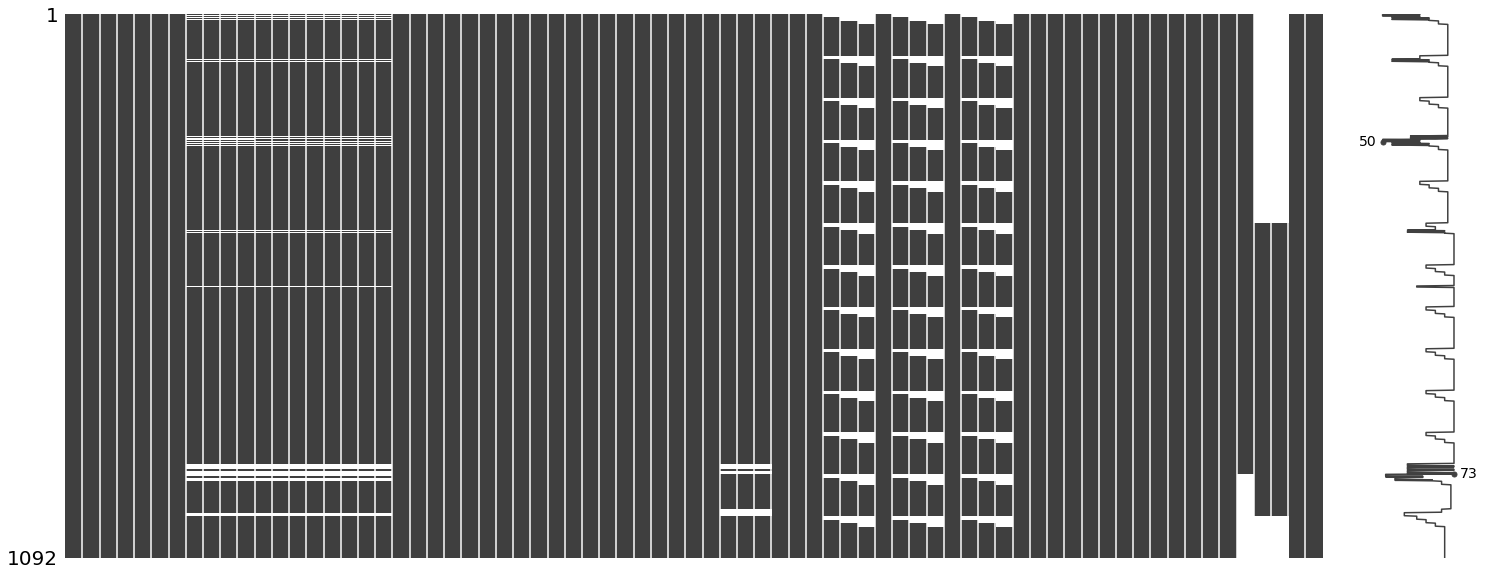

In [106]:
missingno.matrix(dataset_final)

In [107]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2010_2022.csv", encoding = enc, index = False)